In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [45]:
integrated_df = pd.read_csv("../data/processed/integrated.csv")
integrated_df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_year,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Total_children
0,0,38.0,housemaid,MARRIED,basic.4y,0.0,False,False,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857000,5191,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019,161770,1,0,2012-04-04,29,1
1,1,57.0,services,MARRIED,high.school,unknown,False,False,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.626521,5191,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016,85477,1,1,2012-12-30,7,2
2,2,37.0,services,MARRIED,high.school,0.0,True,False,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857000,5191,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019,147233,1,1,2012-02-02,5,2
3,3,40.0,admin.,MARRIED,basic.6y,0.0,False,False,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.625715,5191,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,2015,121393,1,2,2012-12-21,29,3
4,4,56.0,services,MARRIED,high.school,0.0,False,True,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.581983,5191,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017,63164,1,2,2012-06-20,20,3


In [46]:
integrated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42752 non-null  int64  
 1   age                42752 non-null  float64
 2   job                42752 non-null  object 
 3   marital            42752 non-null  object 
 4   education          42752 non-null  object 
 5   default            42752 non-null  object 
 6   housing            42752 non-null  bool   
 7   loan               42752 non-null  bool   
 8   contact            42752 non-null  object 
 9   duration           42752 non-null  int64  
 10  campaign           42752 non-null  int64  
 11  pdays              42752 non-null  int64  
 12  previous           42752 non-null  int64  
 13  poutcome           42752 non-null  object 
 14  emp.var.rate       42752 non-null  float64
 15  cons.price.idx     42752 non-null  float64
 16  cons.conf.idx      427

In [47]:
integrated_df.isna().sum()

Unnamed: 0           0
age                  0
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
date                 0
latitude             0
longitude            0
id_                  0
contact_year         0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
Total_children       0
dtype: int64

In [48]:
integrated_df.duplicated().sum()

np.int64(0)

In [49]:
date_cols = ["date", "contact_year", "Dt_Customer"]
for i in date_cols:
    integrated_df[i] = pd.to_datetime(integrated_df[i])

In [50]:
integrated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         42752 non-null  int64         
 1   age                42752 non-null  float64       
 2   job                42752 non-null  object        
 3   marital            42752 non-null  object        
 4   education          42752 non-null  object        
 5   default            42752 non-null  object        
 6   housing            42752 non-null  bool          
 7   loan               42752 non-null  bool          
 8   contact            42752 non-null  object        
 9   duration           42752 non-null  int64         
 10  campaign           42752 non-null  int64         
 11  pdays              42752 non-null  int64         
 12  previous           42752 non-null  int64         
 13  poutcome           42752 non-null  object        
 14  emp.va

In [51]:
integrated_df.drop(columns="Unnamed: 0", inplace=True)

In [52]:
integrated_df["tenure_years"] = ((integrated_df["date"] - integrated_df["Dt_Customer"]).dt.days/365).round(3)
integrated_df.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_year,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Total_children,tenure_years
0,38.0,housemaid,MARRIED,basic.4y,0.0,False,False,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857000,5191,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,1970-01-01 00:00:00.000002019,161770,1,0,2012-04-04,29,1,7.332
1,57.0,services,MARRIED,high.school,unknown,False,False,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.626521,5191,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1970-01-01 00:00:00.000002016,85477,1,1,2012-12-30,7,2,3.710
2,37.0,services,MARRIED,high.school,0.0,True,False,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857000,5191,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,1970-01-01 00:00:00.000002019,147233,1,1,2012-02-02,5,2,7.041
3,40.0,admin.,MARRIED,basic.6y,0.0,False,False,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.625715,5191,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,1970-01-01 00:00:00.000002015,121393,1,2,2012-12-21,29,3,2.940
4,56.0,services,MARRIED,high.school,0.0,False,True,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,3.581983,5191,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,1970-01-01 00:00:00.000002017,63164,1,2,2012-06-20,20,3,4.614


In [53]:
integrated_df["tenure_years"].describe()

count    42752.000000
mean         4.141702
std          1.724933
min          0.022000
25%          2.871000
50%          4.151000
75%          5.436000
max          8.003000
Name: tenure_years, dtype: float64

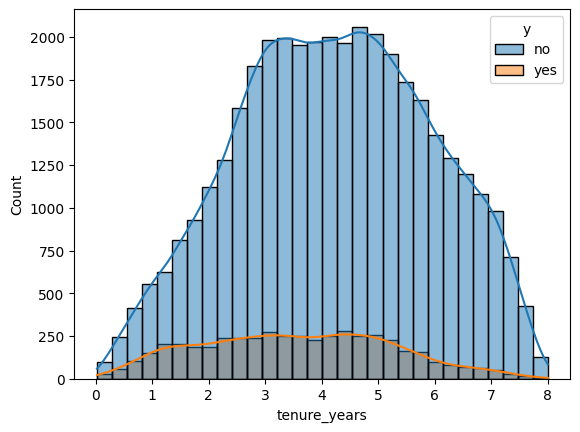

In [54]:
sns.histplot(data=integrated_df, x="tenure_years", hue="y", bins=30, kde=True)
plt.show()
plt.close()

The distribution of customer tenure appears relatively symmetric, with most clients having between 3 and 5 years of relationship with the bank. Visual inspection suggests no strong separation between converters and non-converters based solely on tenure.

In [55]:
mean_tenure_y = integrated_df[integrated_df["y"] == "yes"]["tenure_years"].mean()
mean_tenure_y

np.float64(3.551272500519643)

In [56]:
median_tenure_y = integrated_df[integrated_df["y"] == "yes"]["tenure_years"].median()
median_tenure_y

np.float64(3.529)

In [57]:
mean_tenure_n = integrated_df[integrated_df["y"] == "no"]["tenure_years"].mean()
mean_tenure_n

np.float64(4.216569647610764)

In [58]:
median_tenure_n = integrated_df[integrated_df["y"] == "no"]["tenure_years"].median()
median_tenure_n

np.float64(4.219)

The average tenure of customers who subscribed to the product is slightly lower (3.5 years) compared to those who did not (4.2 years). This suggests that more recently acquired customers may be more receptive to marketing campaigns.

### Income vs Conversion rate

In [59]:
integrated_df["Income"].describe()

count     42752.000000
mean      93225.591504
std       50495.796689
min        5841.000000
25%       49587.500000
50%       93016.000000
75%      136732.000000
max      180802.000000
Name: Income, dtype: float64

In [60]:
mean_income_y = integrated_df[integrated_df["y"]=="yes"]["Income"].mean()
mean_income_y

np.float64(92660.66244024111)

In [61]:
mean_income_n = integrated_df[integrated_df["y"]=="no"]["Income"].mean()
mean_income_n

np.float64(93297.22571887932)

The average income between converters and non-converters is almost identical, suggesting that income level alone does not significantly influence subscription behavior in this campaign.

### NumWebVisitsMonth

In [62]:
integrated_df["NumWebVisitsMonth"].describe()

count    42752.000000
mean        16.590007
std          9.239466
min          1.000000
25%          9.000000
50%         17.000000
75%         25.000000
max         32.000000
Name: NumWebVisitsMonth, dtype: float64

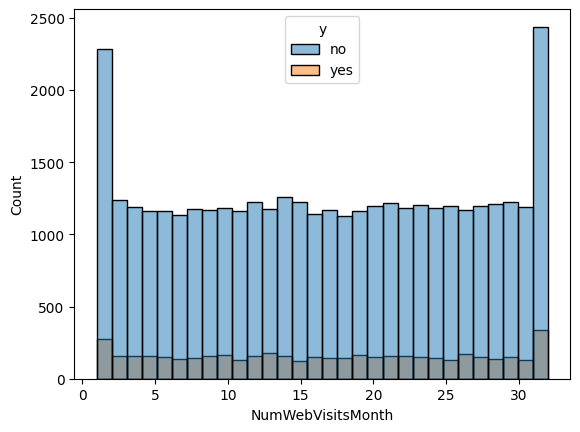

In [63]:
sns.histplot(data=integrated_df, x="NumWebVisitsMonth", hue="y", bins=30)
plt.show()
plt.close()

In [64]:
integrated_df.groupby("y")["NumWebVisitsMonth"].mean()

y
no     16.589942
yes    16.590522
Name: NumWebVisitsMonth, dtype: float64

In [65]:
integrated_df.groupby("y")["NumWebVisitsMonth"].median()

y
no     17.0
yes    17.0
Name: NumWebVisitsMonth, dtype: float64

In [66]:
integrated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                42752 non-null  float64       
 1   job                42752 non-null  object        
 2   marital            42752 non-null  object        
 3   education          42752 non-null  object        
 4   default            42752 non-null  object        
 5   housing            42752 non-null  bool          
 6   loan               42752 non-null  bool          
 7   contact            42752 non-null  object        
 8   duration           42752 non-null  int64         
 9   campaign           42752 non-null  int64         
 10  pdays              42752 non-null  int64         
 11  previous           42752 non-null  int64         
 12  poutcome           42752 non-null  object        
 13  emp.var.rate       42752 non-null  float64       
 14  cons.p

In [67]:
integrated_df["Total_children"].describe()

count    42752.000000
mean         2.003883
std          1.153363
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: Total_children, dtype: float64

In [68]:
integrated_df.groupby("y")["Total_children"].mean()

y
no     2.003980
yes    2.003118
Name: Total_children, dtype: float64

From what we can see with this analysis there is no significant difference in the number of children of customers who subscribed to any product in this campaign compared to those who did not subscribe.
Number of children does not seem to be relevant for this analysis